In [1]:
import pandas as pd  
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("../Data/final/environment_data.csv")

In [3]:
def detect_outliers_iqr(df, city=None):
    if city is not None:
        df = df[df["City"] == city]
    
    outlier_summary = []
    outlier_rows = pd.DataFrame()

    for col in df.select_dtypes(include=['float64', 'int64']).columns:
        if col == "isWeekend" or col=="Electricity Consumption":
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outliers["Outlier_Feature"] = col   
        outlier_rows = pd.concat([outlier_rows, outliers])
        
        outlier_summary.append({
            "Feature": col,
            "Outliers_Count": len(outliers),
            "Lower_Bound": round(lower, 2),
            "Upper_Bound": round(upper, 2)
        })
    
    return pd.DataFrame(outlier_summary), outlier_rows



In [4]:
summary, outlier_rows = detect_outliers_iqr(df, city="London")
print(summary.sort_values(by="Outliers_Count", ascending=False))

             Feature  Outliers_Count  Lower_Bound  Upper_Bound
0              PM2.5              30        -0.39        16.01
4                 CO              28        57.25       312.92
1               PM10              23         0.45        23.58
3                NO2              12        -6.90        42.45
5                SO2              12        -0.81         6.34
2                 O3               8         6.77        93.94
11          Pressure               8       982.32      1040.07
10        Wind_speed               3        -2.85        31.81
7   Temperature_mean               0        -4.80        29.78
6        Green_Space               0       162.00       162.00
9           Humidity               0        49.25       104.58
8    Temperature_max               0        -4.00        36.00


C:\Users\AL SAAD NASR CITY\AppData\Local\Temp\ipykernel_18624\3679754261.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers["Outlier_Feature"] = col
C:\Users\AL SAAD NASR CITY\AppData\Local\Temp\ipykernel_18624\3679754261.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers["Outlier_Feature"] = col
C:\Users\AL SAAD NASR CITY\AppData\Local\Temp\ipykernel_18624\3679754261.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

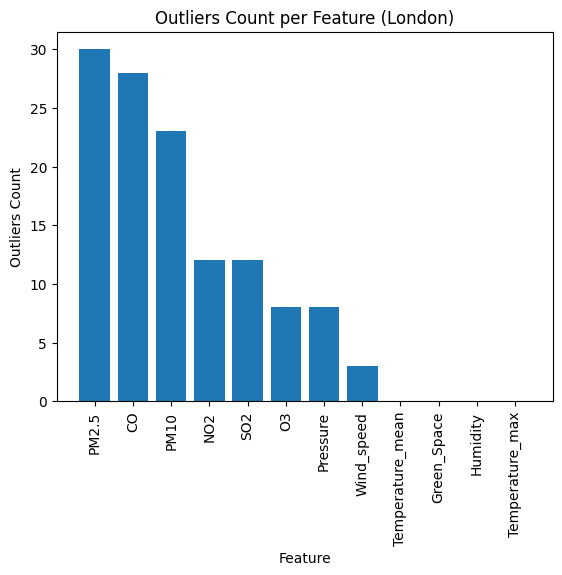

In [5]:


summary_sorted = summary.sort_values(by="Outliers_Count", ascending=False)

plt.figure()
plt.bar(summary_sorted["Feature"], summary_sorted["Outliers_Count"])
plt.xticks(rotation=90)
plt.xlabel("Feature")
plt.ylabel("Outliers Count")
plt.title("Outliers Count per Feature (London)")
plt.show()

Outliers were mainly concentrated in pollution-related features such as PM2.5 NO2, co, and PM10, indicating occasional extreme pollution events in Dubai. Wind speed also showed several outliers, suggesting sudden weather changes. In contrast, temperature, pressure, and electricity consumption remained relatively stable with few or no outliers. Overall, the results suggest that air pollution levels are more variable and prone to sudden spikes compared to other environmental factors.

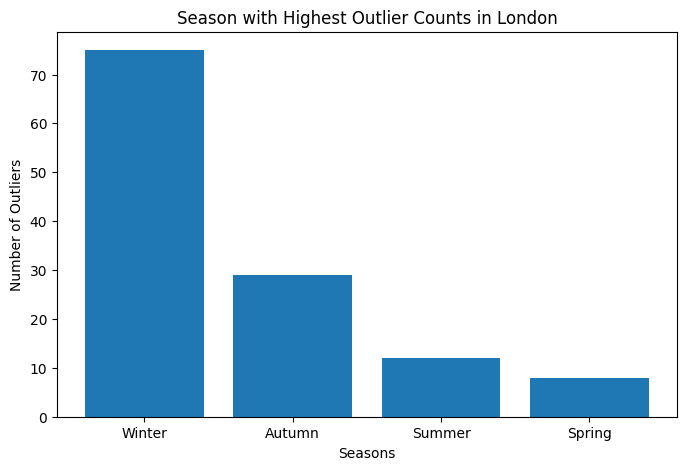

In [11]:
season_outliers = outlier_rows["Season"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(season_outliers.index.astype(str), season_outliers.values)

plt.xlabel("Seasons")
plt.ylabel("Number of Outliers")
plt.title("Season with Highest Outlier Counts in London")

plt.show()

Winter recorded the highest number of outliers in London, indicating greater variability in environmental and pollution-related conditions during colder months. In contrast, Summer and Spring showed fewer outliers, suggesting more stable conditions. This pattern may be linked to winter weather conditions and reduced air circulation.

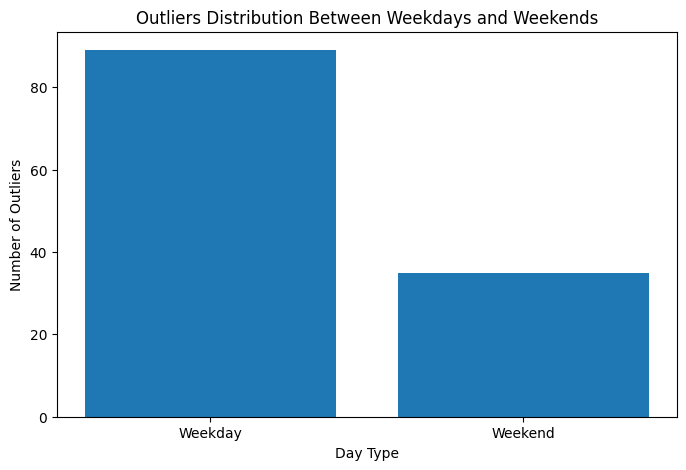

In [7]:
plt.figure(figsize=(8,5))
z=outlier_rows["isWeekend"].value_counts()
plt.bar(z.index.astype(str), z.values)

plt.xlabel("Day Type")
plt.ylabel("Number of Outliers")
plt.title("Outliers Distribution Between Weekdays and Weekends")

plt.xticks([0,1], ["Weekday", "Weekend"])

plt.show()

Severe pollution events in Nairobi appear to be more strongly associated with regular working days and daily human activities rather than weekends or holiday periods.

In [8]:
normal_rows = df[~df.index.isin(outlier_rows.index)]

outliers_mean = outlier_rows.mean(numeric_only=True)
normal_mean = normal_rows.mean(numeric_only=True)

comparison = pd.DataFrame({
    "Outliers": outliers_mean,
    "Normal": normal_mean
})

comparison

,Outliers,Normal
PM2.5,1.974002e+01,2.054009e+01
PM10,2.662356e+01,3.745368e+01
O3,3.104167e+01,5.494556e+01
NO2,3.854879e+01,3.320619e+01
CO,3.531226e+02,3.397605e+02
SO2,5.989079e+00,1.471479e+01
Green_Space,1.620000e+02,1.036512e+02
Temperature_mean,8.223341e+00,1.926639e+01
Temperature_max,1.282258e+01,2.349537e+01
Humidity,8.033374e+01,6.424688e+01


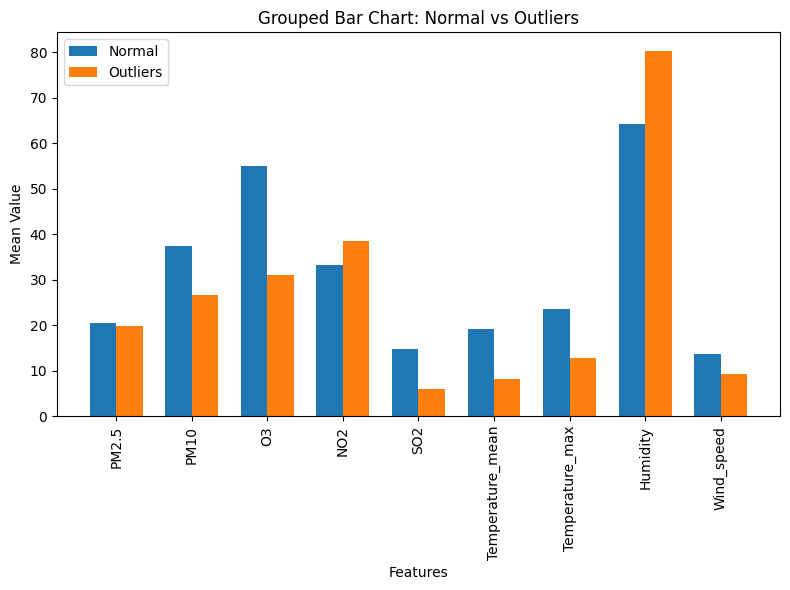

In [9]:

compare = comparison.drop(["Pressure", "isWeekend","CO","Electricity Consumption","Green_Space"])
features = compare.index

x = np.arange(len(features))
width = 0.35

plt.figure(figsize=(8,6))

plt.bar(
    x - width/2,
    compare["Normal"],
    width=width,
    label="Normal"
)

plt.bar(
    x + width/2,
    compare["Outliers"],
    width=width,
    label="Outliers"
)

plt.xticks(x, features, rotation=90)

plt.xlabel("Features")
plt.ylabel("Mean Value")
plt.title("Grouped Bar Chart: Normal vs Outliers")

plt.legend()

plt.tight_layout()

plt.show()

Outlier observations showed significantly higher humidity and NO2 levels compared to normal data, while most other environmental variables such as O3, SO2, temperature, and wind speed tended to decrease during outlier events.

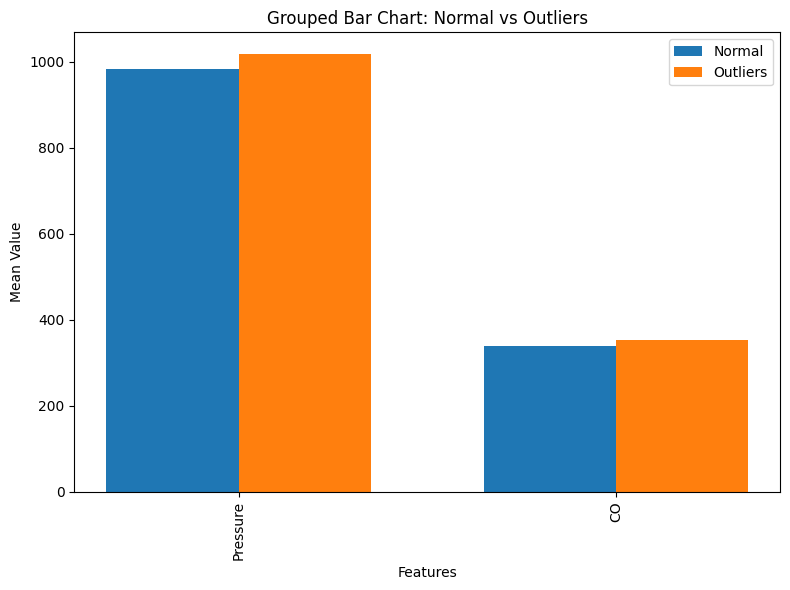

In [10]:
others= comparison.loc[["Pressure","CO"],:]
plt.figure(figsize=(8,6))
features=others.index
x=np.arange(len(features))
width=0.35
plt.bar(
    x-width/2,
    others["Normal"],
    width=width,
    label="Normal"
)
plt.bar(
    x+width/2,
    others["Outliers"],
    width=width,
    label="Outliers"
)
plt.xticks(x, features, rotation=90)

plt.xlabel("Features")
plt.ylabel("Mean Value")
plt.title("Grouped Bar Chart: Normal vs Outliers")
plt.legend()
plt.tight_layout()
plt.show()

Pressure and CO values during outlier events were very close to normal observations, suggesting that these features were not significantly affected during abnormal conditions.
